# Rep. 4 Checkpoint 4. Opciones Americanas con CRR
Gonzalo Cano Padilla

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def arbol_crr(S0, K, r, T, sigma, N, option='call', style='european'):
    """
    Árbol binomial CRR para opciones europeas o americanas.

    S0     : precio inicial
    K      : strike
    r      : tasa libre de riesgo
    T      : tiempo al vencimiento en años
    sigma  : volatilidad
    N      : número de pasos
    option : 'call' o 'put'
    style  : 'european' o 'american'
    """
    dt = T / N
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1 / u
    p  = (np.exp(r * dt) - d) / (u - d)
    df = np.exp(-r * dt)   # factor de descuento por paso

    # --- Árbol de precios al vencimiento ---
    # ST[i] = S0 * u^(N-i) * d^i  para i = 0, 1, ..., N
    ST = np.array([S0 * (u**(N-i)) * (d**i) for i in range(N+1)])

    # --- Valores de la opción al vencimiento ---
    if option == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)


    # --- Inducción hacia atrás ---
    for step in range(N-1, -1, -1):

        S_step = np.array([S0 * (u**(step-i)) * (d**i) for i in range(step+1)])
        # Valor de continuar (esperanza descontada)
        V_continuar = df * (p * V[:step+1] + (1-p) * V[1:step+2])
        if style == 'american':
            # Valor de ejercer ahora
            if option == 'call':
                V_ejercer = np.maximum(S_step - K, 0)
            else:
                V_ejercer = np.maximum(K - S_step, 0)
            V = np.maximum(V_continuar, V_ejercer)

        else:
            V = V_continuar

    return V[0]

# Parámetros
S0    = 680
K     = 700
r     = 0.042
T     = 31/365
sigma = 0.1687
N     = 100

precio_euro_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'european')
precio_amer_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'american')
precio_euro_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'european')
precio_amer_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'american')

print(f"Call europea  : ${precio_euro_call:.4f}")
print(f"Call americana: ${precio_amer_call:.4f}  (prima por ejercicio anticipado: ${precio_amer_call - precio_euro_call:.4f})")
print(f"Put europea   : ${precio_euro_put:.4f}")
print(f"Put americana : ${precio_amer_put:.4f}  (prima por ejercicio anticipado: ${precio_amer_put - precio_euro_put:.4f})")


Call europea  : $6.4979
Call americana: $6.4979  (prima por ejercicio anticipado: $0.0000)
Put europea   : $24.0053
Put americana : $24.4776  (prima por ejercicio anticipado: $0.4723)


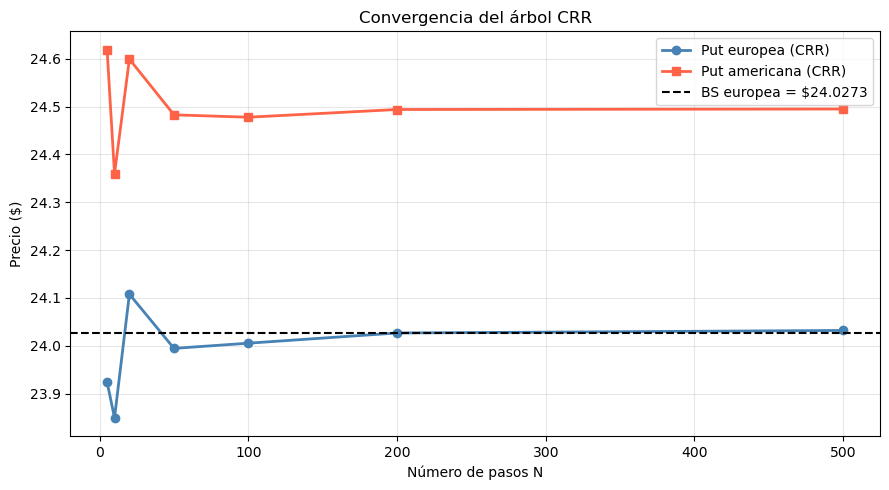

In [7]:
# Precio vs. número de pasos
pasos   = [5, 10, 20, 50, 100, 200, 500]
precios_euro = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'european') for n in pasos]
precios_amer = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'american') for n in pasos]

# Precio BS como referencia
from scipy.stats import norm
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_put = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

plt.figure(figsize=(9, 5))
plt.plot(pasos, precios_euro, marker='o', color='steelblue',
         linewidth=2, label='Put europea (CRR)')
plt.plot(pasos, precios_amer, marker='s', color='tomato',
         linewidth=2, label='Put americana (CRR)')
plt.axhline(bs_put, color='black', linestyle='--',
            label=f'BS europea = ${bs_put:.4f}')
plt.xlabel('Número de pasos N')
plt.ylabel('Precio ($)')
plt.title('Convergencia del árbol CRR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


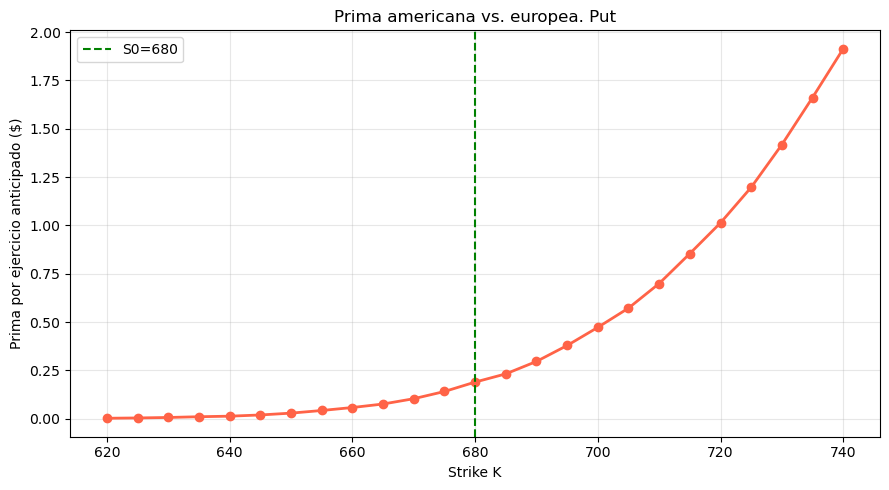

In [8]:
K_range      = np.arange(620, 741, 5)
prima_antic  = []

for k in K_range:
    euro = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'european')
    amer = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'american')
    prima_antic.append(amer - euro)

plt.figure(figsize=(9, 5))
plt.plot(K_range, prima_antic, color='tomato', linewidth=2, marker='o')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Strike K')
plt.ylabel('Prima por ejercicio anticipado ($)')
plt.title('Prima americana vs. europea. Put')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

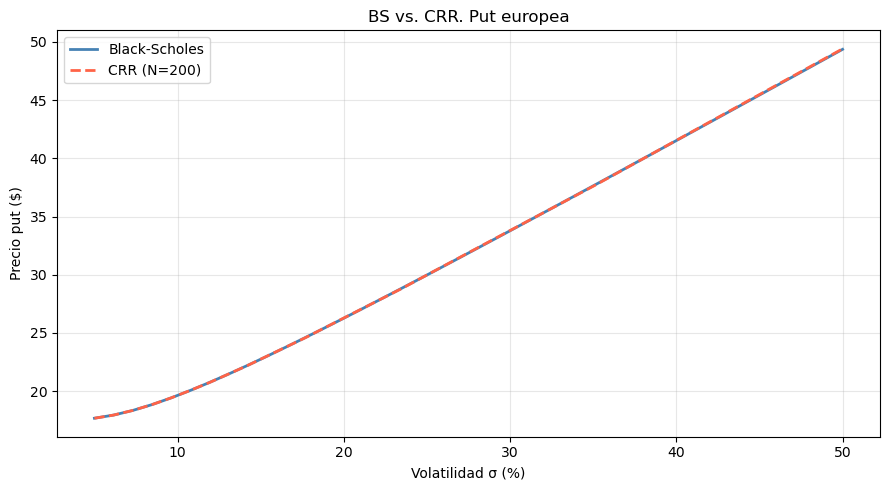

In [9]:
sigma_range  = np.linspace(0.05, 0.50, 40)
bs_precios   = []
crr_precios  = []

for s in sigma_range:
    d1 = (np.log(S0/K) + (r + 0.5*s**2)*T) / (s*np.sqrt(T))
    d2 = d1 - s*np.sqrt(T)
    bs_precios.append(K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1))
    crr_precios.append(arbol_crr(S0, K, r, T, s, 200, 'put', 'european'))

plt.figure(figsize=(9, 5))
plt.plot(sigma_range*100, bs_precios,  color='steelblue', linewidth=2,
         label='Black-Scholes')
plt.plot(sigma_range*100, crr_precios, color='tomato',    linewidth=2,
         linestyle='--', label='CRR (N=200)')
plt.xlabel('Volatilidad σ (%)')
plt.ylabel('Precio put ($)')
plt.title('BS vs. CRR. Put europea')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Preguntas de análisis

**1. ¿Por qué el ejercicio anticipado de una call sobre un activo sin dividendos nunca es óptimo? ¿Qué cambia si el activo paga dividendos?**

Nuestros resultados lo confirman: la call americana y la europea valen exactamente lo mismo (USD 6.4979, prima por ejercicio anticipado = USD 0.0000). La razón es que ejercer anticipadamente una call implica pagar el strike hoy y perder el valor tiempo del dinero y la optionalidad restante. Es siempre mejor vender la call en el mercado o simplemente mantenerla. Si el activo paga dividendos, el precio de la acción cae el día ex-dividendo, lo que reduce el valor de la call; en ese caso puede ser óptimo ejercer justo antes del pago para capturar el dividendo, por lo que la call americana sí tendría una prima adicional.

---

**2. En la gráfica de convergencia, ¿por qué el precio oscila antes de converger? ¿Qué relación tiene con si N es par o impar?**

La oscilación se debe a que la estructura del árbol cambia según la paridad de N. Cuando N es par, un nodo terminal cae exactamente en el strike (o muy cerca), lo que altera la forma en que se valúa la opción en ese punto. Con N impar, ningún nodo coincide exactamente con K, y el perfil de payoff se estima de manera diferente. Este efecto se atenúa conforme N crece y los pasos dt se vuelven muy pequeños, razón por la que el precio converge al valor de Black-Scholes desde ambos lados.

---

**3. La prima por ejercicio anticipado es mayor para puts muy ITM. ¿Por qué tiene sentido ejercer anticipadamente una put muy ITM?**

Cuando una put está muy ITM (K ≫ S0), ya acumuló casi todo su valor intrínseco posible (K − S). Ejercerla hoy significa recibir ese dinero de inmediato e invertirlo a la tasa libre de riesgo. Si se espera al vencimiento, se renuncia a esos intereses y además se corre el riesgo de que el precio rebote y la opción pierda valor intrínseco. El valor tiempo que se "sacrifica" al ejercer es muy pequeño comparado con el beneficio de cobrar ya, por eso la prima americana sobre la europea crece conforme el strike sube y la opción se mete más en el dinero.

---

**4. Si modificas T a 31 días y luego a 1 año, ¿cómo esperas que cambie la diferencia entre la put americana y la europea?**

Con T muy corto (días), el tiempo restante es tan pequeño que ejercer hoy y esperar al vencimiento casi dan el mismo resultado; la diferencia americana-europea es pequeña (como vemos en nuestra base de USD 0.4723 con 31 días). Con T = 1 año, hay muchos más nodos donde el árbol identifica que ejercer anticipadamente supera el valor de continuar; además, el beneficio de recibir el intrínseco hoy y ganar intereses durante un año es más relevante. Por eso la diferencia americana-europea **aumenta conforme T crece** cuando la put es ITM.

---

**5. El árbol CRR usa probabilidades neutrales al riesgo p, no probabilidades reales. ¿Qué significa eso y por qué es válido para el pricing?**

Las probabilidades neutrales al riesgo no son las probabilidades reales de que el precio suba o baje: son valores artificiales construidos para que el activo crezca exactamente a la tasa libre de riesgo en esperanza. Esto es válido por el principio de no-arbitraje: si dos portafolios replican los mismos flujos en todos los escenarios posibles, deben tener el mismo precio hoy, independientemente de cuán probable sea cada escenario. Al valutar bajo la medida neutral al riesgo, podemos descontar al tipo libre de riesgo y obtener el único precio consistente con la ausencia de arbitraje, sin necesidad de conocer el retorno esperado real del activo ni las preferencias de riesgo de los inversores.